# Problem Statement

Predict whether a patient has diabetes based on diagnostic measurements.

Target:
Outcome

Type:
Binary Classification

In [29]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [31]:
# Data Ingestion
df = pd.read_csv('diabetes.csv')
df = df.copy()

In [32]:
# Understanding the DataSet (EDA)
df.shape

(768, 9)

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [37]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [38]:
df.duplicated().sum()

np.int64(0)

In [40]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [41]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [42]:
cols = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

(df[cols] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [43]:
(df[cols] == 0).sum().sort_values(ascending=False)

Insulin          374
SkinThickness    227
BloodPressure     35
BMI               11
Glucose            5
dtype: int64

In [44]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [45]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [48]:
# Analyzing the distribution of your target variable.
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [49]:
df["Outcome"].value_counts(normalize=True)

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

In [51]:
# data cleaning
# Replace invalid values
df[cols] = df[cols].replace(0, np.nan)
(df[cols] == 0).sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

In [52]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [53]:
# Separate features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [54]:
# Split Dataset
# Used stratify to keeps class distribution balanced.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [55]:
# Data preprocessing & Training pipeline
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

fitted_models = {}

for name, model in models.items():

    if name == 'Logistic Regression':
        # Pre-Processing
        pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", model)
        ])
    else:
        pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", model)
        ])

    # Training
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline

lr = fitted_models["Logistic Regression"]
rf = fitted_models["Random Forest"]
xgb = fitted_models["XGBoost"]
cb = fitted_models["CatBoost"]


In [56]:
# Evaluate Models
results = []

for model in [lr, rf, xgb, cb]:

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model.named_steps["model"].__class__.__name__,
        "Train Score": model.score(X_train, y_train),
        "Test Score": model.score(X_test, y_test),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df["Gap"] = (
    results_df["Train Score"] -
    results_df["Test Score"]
)

results_df.sort_values("ROC_AUC", ascending=False)

,Model,Train Score,Test Score,Accuracy,Precision,Recall,F1,ROC_AUC,Gap
3,CatBoostClassifier,0.941368,0.746753,0.746753,0.653061,0.592593,0.621359,0.823704,0.194615
1,RandomForestClassifier,1.000000,0.753247,0.753247,0.642857,0.666667,0.654545,0.821481,0.246753
0,LogisticRegression,0.758958,0.733766,0.733766,0.603175,0.703704,0.649573,0.812593,0.025191
2,XGBClassifier,1.000000,0.766234,0.766234,0.687500,0.611111,0.647059,0.810185,0.233766


In [20]:
# The real goal :
# You're not saying:
# "LR is the final winner."
# You're saying:
# "LR is the most promising candidate, so let's optimize it and see if it becomes an even better model."
# After tuning and cross-validation, it's still possible that Logistic Regression ends up being the final production model if:
# Tuned LR doesn't improve much, or
# LR remains highly unstable across folds.
# # Tune best model with parameters that reduce overfitting
# Compare Models
# ↓
# Select Most Promising Model (LR)
# ↓
# Tune LR/ Evaluate
# ↓
# Cross Validate LR
# ↓
# Compare with Logistic Regression
# ↓
# Choose Final Model
# So LR was selected because it currently has the best predictive performance, even though it still needs work to reduce overfitting.

In [57]:
# Tuning best model
# Define Parameter Search Space
lr_params = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"],
    "model__class_weight": [None, "balanced"],
}

# Create RandomizedSearchCV
lr_search = RandomizedSearchCV(
    estimator=lr,
    param_distributions=lr_params,
    n_iter=20,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

# Fit Search Object
lr_search.fit(X_train, y_train)

# View Best Parameters
print("Best Parameters:")
print(lr_search.best_params_)

print("\nBest CV Score:")
print(lr_search.best_score_)

Best Parameters:
{'model__solver': 'liblinear', 'model__penalty': 'l2', 'model__class_weight': None, 'model__C': 1}

Best CV Score:
0.8430564784053155


c:\Users\User\miniconda3\envs\diabetes_proj_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [58]:
# Get Best Tuned Pipeline
best_lr = lr_search.best_estimator_


Threshold Optimization

The default threshold of 0.5 was adjusted to 0.30
to improve recall and reduce false negatives.

This increased Recall from 0.703 to 0.796 while maintaining
an acceptable Precision and F1-score.

In [59]:
# Evaluate Tuned Model
# y_pred = best_lr.predict(X_test)
y_prob = best_lr.predict_proba(X_test)[:, 1]
threshold = 0.30
y_pred = (y_prob >= threshold).astype(int)


print("Train Accuracy:", best_lr.score(X_train, y_train))
print("Test Accuracy:", best_lr.score(X_test, y_test))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print("\nPrecision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Train Accuracy: 0.7964169381107492
Test Accuracy: 0.6948051948051948
ROC AUC: 0.8127777777777777

Precision: 0.5972222222222222
Recall: 0.7962962962962963
F1 Score: 0.6825396825396826


In [60]:
# Classification Report -
# A Classification Report is a summary of how well your classification model predicts each class.

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.71      0.78       100
           1       0.60      0.80      0.68        54

    accuracy                           0.74       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.77      0.74      0.75       154

Confusion Matrix:
 [[71 29]
 [11 43]]


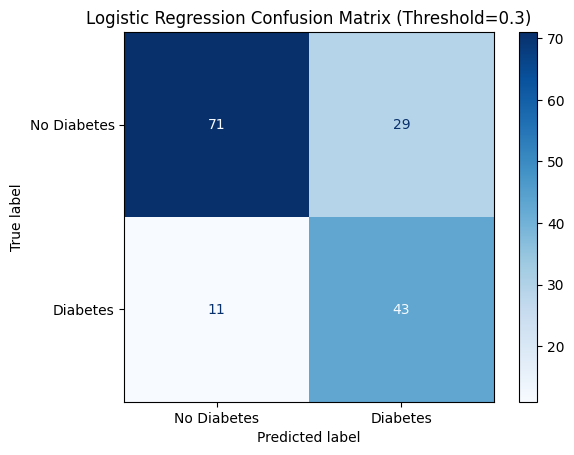

In [61]:
# Confusion Matrix - helps understand false positives and false negatives.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Diabetes", "Diabetes"],
    cmap="Blues",
    values_format="d"
)

plt.title(f"Logistic Regression Confusion Matrix (Threshold={threshold})")
plt.show()

In [62]:
cv_results = []

models = {
    "Logistic Regression": lr,
    "Tuned Logistic Regression": best_lr

}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Mean ROC-AUC": scores.mean(),
        "CV Std": scores.std(),
        "Min Score": scores.min(),
        "Max Score": scores.max()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="CV Mean ROC-AUC",
    ascending=False
)

display(cv_results_df)

,Model,CV Mean ROC-AUC,CV Std,Min Score,Max Score
1,Tuned Logistic Regression,0.843056,0.029111,0.790698,0.869643
0,Logistic Regression,0.841596,0.028935,0.792151,0.868605


In [63]:
model_artifact = {
    "model": best_lr,
    "features": X.columns.tolist(),
    "target": "Outcome",
    "threshold": 0.30
}

joblib.dump(
    model_artifact,
    "diabetes_prediction_model.pkl"
)

['diabetes_prediction_model.pkl']

In [64]:
# Inference Test

artifact = joblib.load("diabetes_prediction_model.pkl")
loaded_model = artifact["model"]

sample = X_test.iloc[[0]]

threshold = artifact["threshold"]

proba = loaded_model.predict_proba(sample)[0][1]
pred = int(proba >= threshold)

print(f"Probability of Diabetes: {proba:.3f}")
print(f"Threshold: {threshold}")
print(f"Prediction: {'Diabetes Risk' if pred else 'No Diabetes Risk'}")
print(f"Actual Label: {y_test.iloc[0]}")

Probability of Diabetes: 0.612
Threshold: 0.3
Prediction: Diabetes Risk
Actual Label: 0


# Conclusion:

Selected Model: Tuned Logistic Regression

# Reason for Selection:
- CV ROC-AUC ≈ 0.843
- Stable across folds
- Highest F1 among tested models
- Very high recall after threshold optimization
- Easy to explain and deploy